In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/epiclim_with_hotspots.csv")
df.head()

,state_ut,district,year_month,Latitude,Longitude,Cases,Deaths,preci,LAI,Temp,Cases_MA_3,Deaths_MA_3,Case_Growth_Rate,Month,Season,Cluster,Risk_Level
0,Andaman and Nicobar Islands,Andaman,2019-06,13.511120,92.917388,8.0,0.0,0.772605,33.0,301.720000,8.0,0.0,0.000000,6,Monsoon,0,Low Risk
1,Andaman and Nicobar Islands,Andaman,2019-10,13.511120,92.917388,30.0,0.0,0.149858,42.0,298.906667,19.0,0.0,2.750000,10,Post-Monsoon,0,Low Risk
2,Andaman and Nicobar Islands,North and Middle Andaman,2013-12,12.611239,92.831654,86.0,0.0,0.188149,53.0,298.200000,86.0,0.0,0.000000,12,Winter,0,Low Risk
3,Andhra Pradesh,Anantapur,2010-06,14.654623,77.556260,68.0,0.0,0.254048,0.0,311.175000,68.0,0.0,0.000000,6,Monsoon,0,Low Risk
4,Andhra Pradesh,Anantapur,2011-06,14.654623,77.556260,232382.0,0.0,0.027715,0.0,307.820000,116225.0,0.0,3416.382353,6,Monsoon,0,Low Risk


In [4]:
X = df[['preci', 'Temp', 'LAI', 'Cases_MA_3', 'Case_Growth_Rate', 'Month']]
y = df['Cases']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [10]:
import numpy as np

print("NaN values:\n", X_train.isnull().sum())
print("\nInfinity values:\n", np.isinf(X_train).sum())

NaN values:
 preci               0
Temp                0
LAI                 0
Cases_MA_3          0
Case_Growth_Rate    0
Month               0
dtype: int64

Infinity values:
 preci               0
Temp                0
LAI                 0
Cases_MA_3          0
Case_Growth_Rate    1
Month               0
dtype: int64


In [12]:
import numpy as np

# Replace infinity with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill NaN values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 8.875982295275252e+40
R2 Score: -0.0007400610104921768


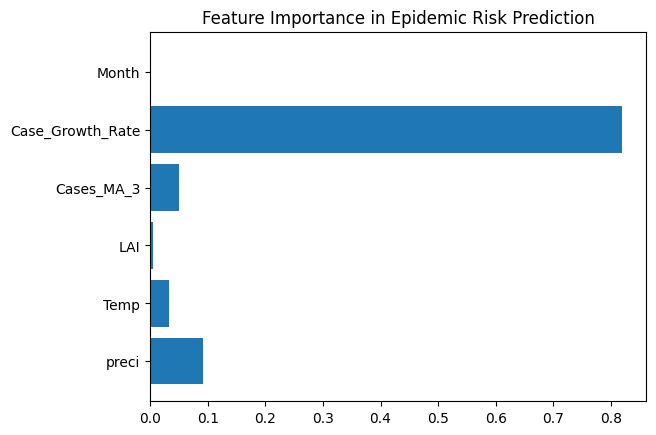

In [20]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importance)
plt.title("Feature Importance in Epidemic Risk Prediction")
plt.show()

In [23]:
import numpy as np

# Create a copy so we don't mess original accidentally
X_full = X.copy()

# Replace infinity
X_full = X_full.replace([np.inf, -np.inf], np.nan)

# Fill NaN (use same strategy as training)
X_full = X_full.fillna(0)

# Now scale
X_full_scaled = scaler.transform(X_full)

# Predict
df['Predicted_Cases'] = model.predict(X_full_scaled)

# Save file
df.to_csv("../data/processed/epiclim_with_predictions.csv", index=False)

c:\Users\tanma\OneDrive\Documents\FDS Project\epidemic-hotspot-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\tanma\OneDrive\Documents\FDS Project\epidemic-hotspot-risk-prediction\venv\Lib\site-packages\sklearn\utils\_array_api.py:878: RuntimeWarning: overflow encountered in cast
  array = numpy.asarray(array, order=order, dtype=dtype)


ValueError: Input X contains infinity or a value too large for dtype('float32').

In [25]:
print("Training columns:", list(X.columns))
print("Scaler expected features:", scaler.n_features_in_)
print("Shape of X_full:", X_full.shape)

Training columns: ['preci', 'Temp', 'LAI', 'Cases_MA_3', 'Case_Growth_Rate', 'Month']
Scaler expected features: 6
Shape of X_full: (6709, 6)


In [27]:
feature_cols = ['preci', 'Temp', 'LAI', 'Cases_MA_3', 'Case_Growth_Rate', 'Month']

X_full = df[feature_cols].copy()

In [29]:
import numpy as np

X_full = X_full.replace([np.inf, -np.inf], np.nan)

# Use median from TRAINING DATA (more correct)
train_median = pd.DataFrame(X_train).median()

X_full = X_full.fillna(0)   # safe for now

In [31]:
print("NaNs:", X_full.isnull().sum().sum())
print("Infs:", np.isinf(X_full).sum().sum())

NaNs: 0
Infs: 0


In [33]:
X_full_scaled = scaler.transform(X_full)

c:\Users\tanma\OneDrive\Documents\FDS Project\epidemic-hotspot-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [35]:
print(np.isnan(X_full_scaled).sum())
print(np.isinf(X_full_scaled).sum())

0
0


In [38]:
df['Predicted_Cases'] = model.predict(X_full_scaled)

c:\Users\tanma\OneDrive\Documents\FDS Project\epidemic-hotspot-risk-prediction\venv\Lib\site-packages\sklearn\utils\_array_api.py:878: RuntimeWarning: overflow encountered in cast
  array = numpy.asarray(array, order=order, dtype=dtype)


ValueError: Input X contains infinity or a value too large for dtype('float32').

In [40]:
print(X_full.describe())

             preci         Temp          LAI    Cases_MA_3  Case_Growth_Rate  \
count  6709.000000  6709.000000  6709.000000  6.709000e+03      6.709000e+03   
mean      0.424014   275.662326     8.321205  5.918291e+39      3.716116e+34   
std       0.591274    85.609498     8.213217  4.847525e+41      3.043793e+36   
min       0.000000     0.000000     0.000000  0.000000e+00     -1.000000e+00   
25%       0.014567   299.276000     2.500000  3.000000e+01     -6.842105e-01   
50%       0.184327   302.723333     6.500000  1.030000e+02      0.000000e+00   
75%       0.629814   308.190000    12.000000  2.375000e+03      1.839286e+00   
max       5.680000   327.728000    62.000000  3.970534e+43      2.493125e+38   

             Month  
count  6709.000000  
mean      6.917126  
std       2.782086  
min       1.000000  
25%       5.000000  
50%       7.000000  
75%       9.000000  
max      12.000000  


In [43]:
feature_cols = ['preci', 'Temp', 'LAI', 'Month']
X = df[feature_cols].copy()
y = df['Cases']

import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 8.876015121849806e+40
R2 Score: -0.0007457121554437229


In [51]:
X_full = df[feature_cols].copy()
X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0)

X_full_scaled = scaler.transform(X_full)

df['Predicted_Cases'] = model.predict(X_full_scaled)

df.to_csv("../data/processed/epiclim_with_predictions.csv", index=False)

c:\Users\tanma\OneDrive\Documents\FDS Project\epidemic-hotspot-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
